# Bank Customer Intelligence System
## Exploratory Data Analysis (EDA)

This notebook explores the Bank Marketing Dataset before data preprocessing and model training.

In [2]:
from pathlib import Path 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Dataset

In [3]:
DATA_PATH = Path("../dataset/bank-full.csv")
DATA_PATH.exists()


True

In [5]:
df =pd.read_csv(DATA_PATH ,  sep=";")
df.shape

(45211, 17)

## 3. Initial Data Inspection

In [6]:
print(df.head())

   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  


In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
None


In [8]:
print(df.describe())

                age        balance           day      duration      campaign  \
count  45211.000000   45211.000000  45211.000000  45211.000000  45211.000000   
mean      40.936210    1362.272058     15.806419    258.163080      2.763841   
std       10.618762    3044.765829      8.322476    257.527812      3.098021   
min       18.000000   -8019.000000      1.000000      0.000000      1.000000   
25%       33.000000      72.000000      8.000000    103.000000      1.000000   
50%       39.000000     448.000000     16.000000    180.000000      2.000000   
75%       48.000000    1428.000000     21.000000    319.000000      3.000000   
max       95.000000  102127.000000     31.000000   4918.000000     63.000000   

              pdays      previous  
count  45211.000000  45211.000000  
mean      40.197828      0.580323  
std      100.128746      2.303441  
min       -1.000000      0.000000  
25%       -1.000000      0.000000  
50%       -1.000000      0.000000  
75%       -1.000000      0.

In [9]:
df.describe(include="object")

,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
unique,12,3,4,2,2,2,3,12,4,2
top,blue-collar,married,secondary,no,yes,no,cellular,may,unknown,no
freq,9732,27214,23202,44396,25130,37967,29285,13766,36959,39922


## 4. Data Quality Checks

In [10]:
print(df.isnull().sum())
print(".................") 
print("The duplicate values are : " , df.duplicated().sum())
print(" the unknow things include objects are :")
(df.select_dtypes(include="object") == "unknown").sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64
.................
The duplicate values are :  0
 the unknow things include objects are :


job            288
marital          0
education     1857
default          0
housing          0
loan             0
contact      13020
month            0
poutcome     36959
y                0
dtype: int64

In [11]:
unknown_percentage = (
    (df.select_dtypes(include="object") == "unknown").sum()
    / len(df)
    * 100
).round(2)

unknown_percentage[unknown_percentage > 0]

job           0.64
education     4.11
contact      28.80
poutcome     81.75
dtype: float64

## 5. Target Variable Analysis

In [12]:
df["y"].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

In [13]:
df["y"].value_counts(normalize=True).mul(100).round(2)

y
no     88.3
yes    11.7
Name: proportion, dtype: float64

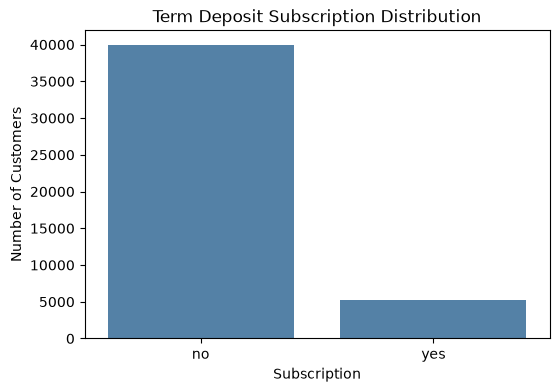

In [14]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="y", color="steelblue")

plt.title("Term Deposit Subscription Distribution")
plt.xlabel("Subscription")
plt.ylabel("Number of Customers")
plt.show()

## 6. Numerical Features Analysis

In [15]:
numerical_columns = df.select_dtypes(include="number").columns.tolist()
numerical_columns

['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

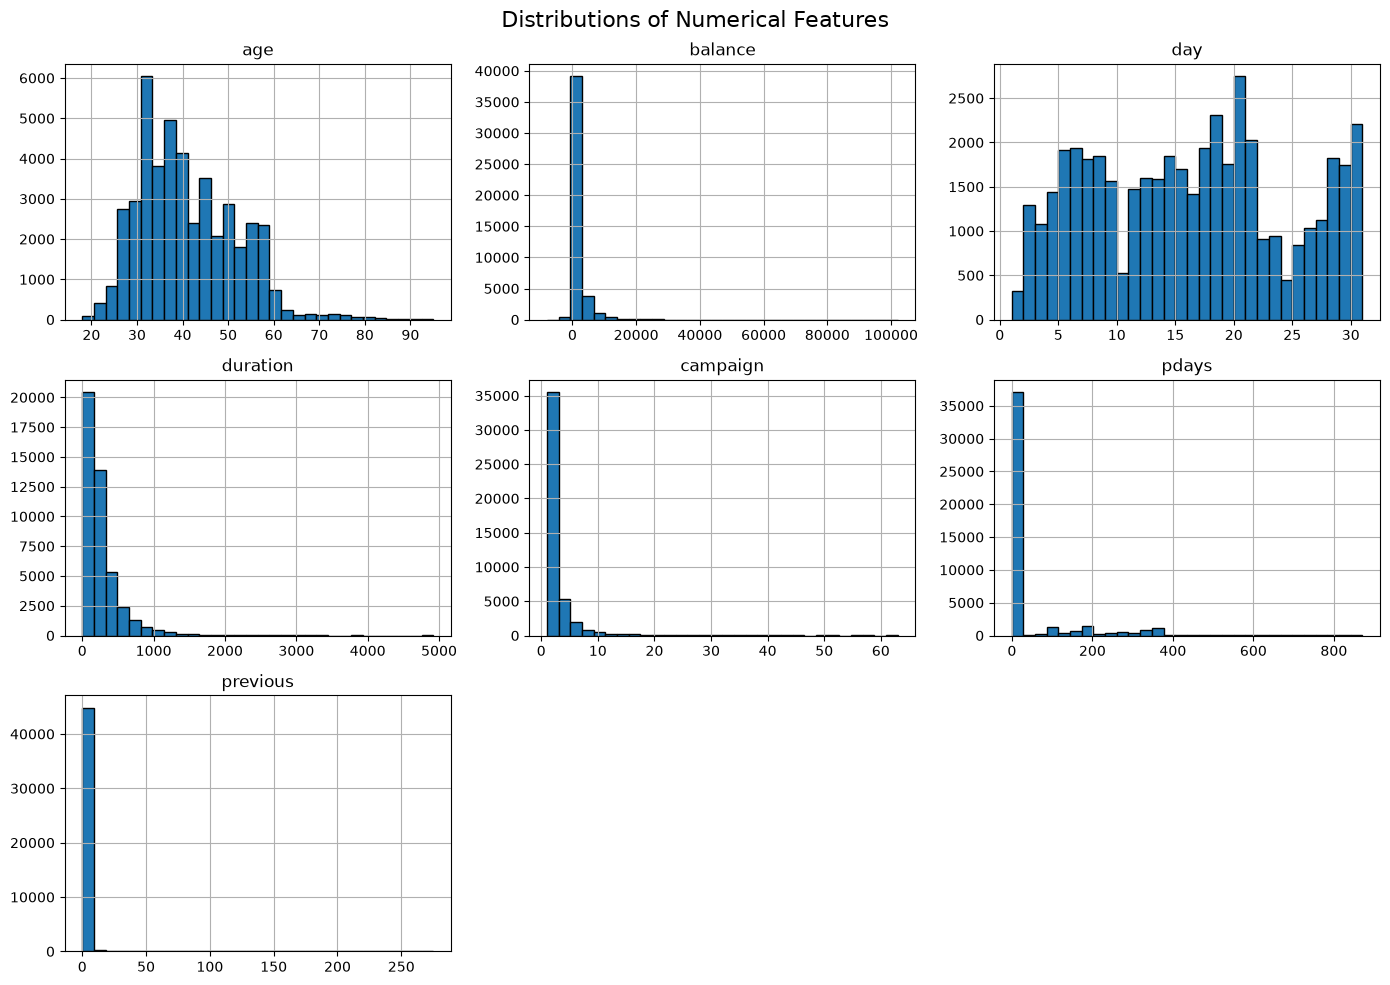

In [16]:
df[numerical_columns].hist(
    figsize=(14, 10),
    bins=30,
    edgecolor="black"
)

plt.suptitle("Distributions of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()


### Numerical Distribution Observations

- Most customers are between approximately 25 and 60 years old.
- Balance is strongly right-skewed and contains possible extreme values.
- The contact day is distributed across the days of the month.
- Duration is right-skewed and will later be removed to prevent data leakage.
- Campaign is right-skewed, with most customers contacted only a few times.
- Most customers were not contacted in a previous campaign, represented by `pdays = -1`.
- Most customers have zero previous campaign contacts.

## 7. Outlier Detection

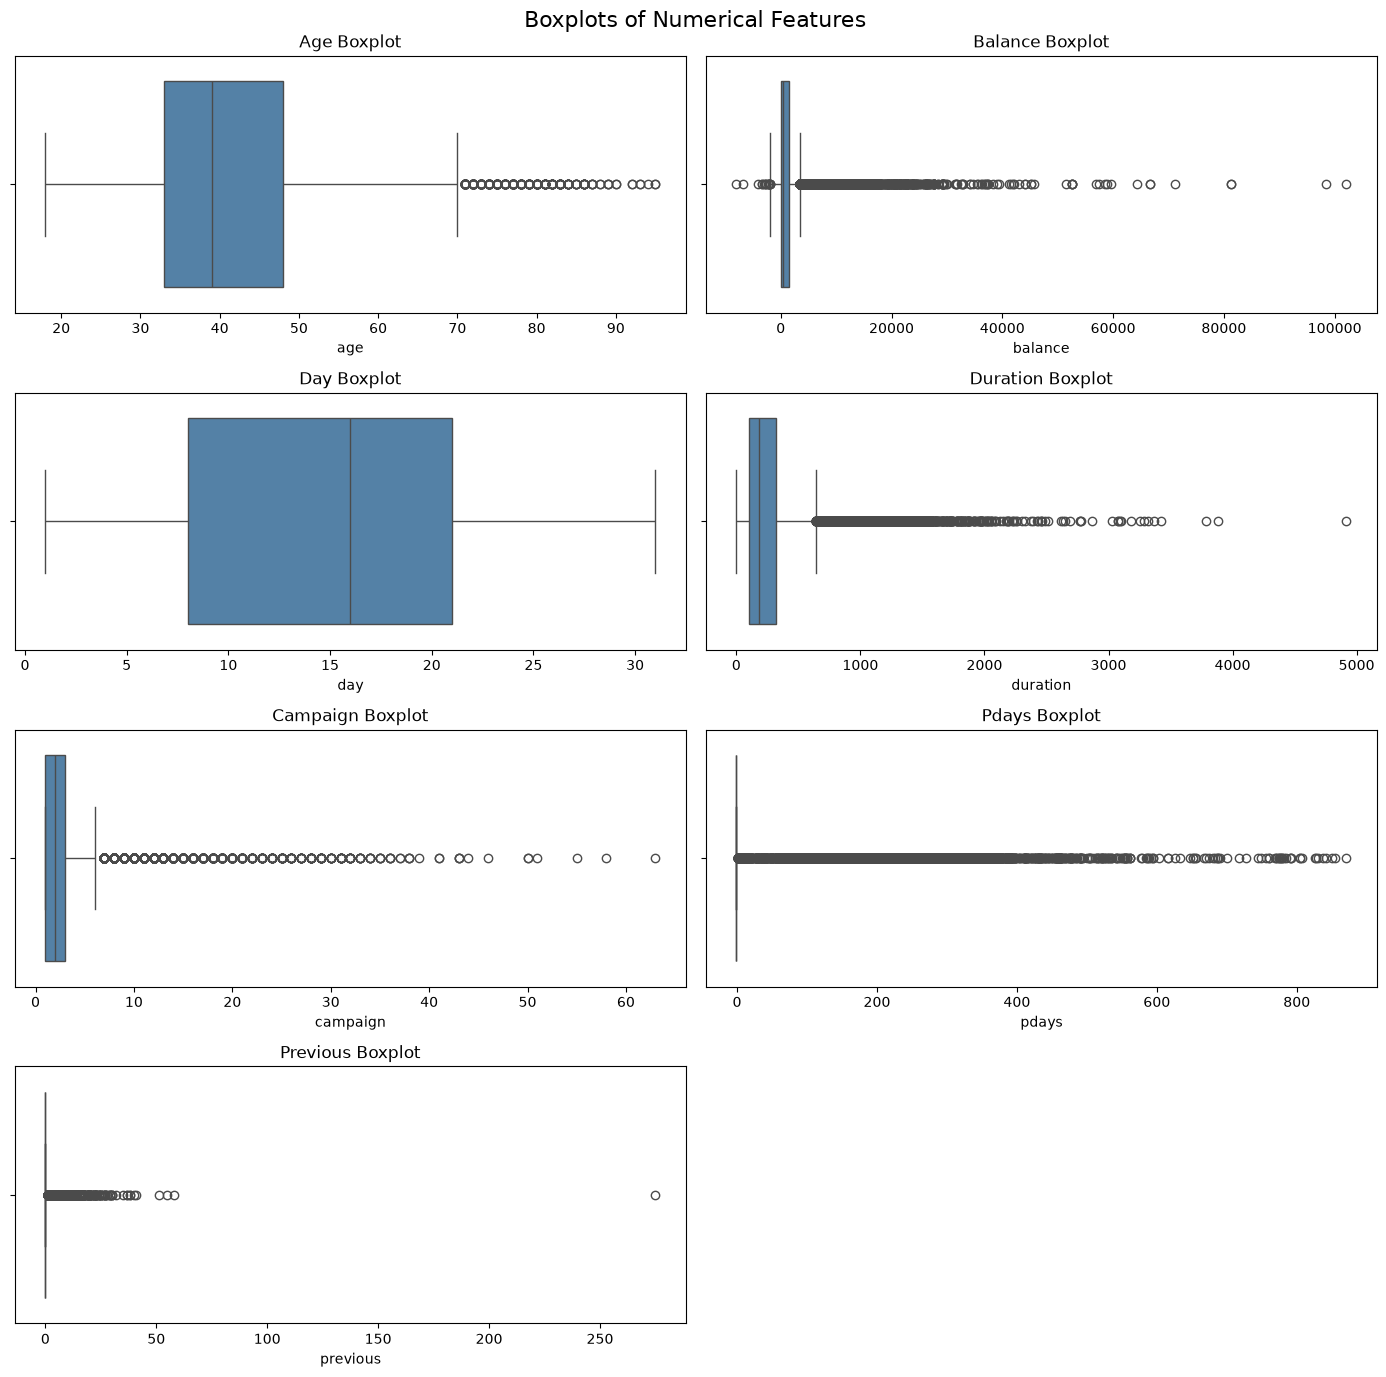

In [17]:
fig, axes = plt.subplots(4, 2, figsize=(14, 14))
axes = axes.flatten()

for index, column in enumerate(numerical_columns):
    sns.boxplot(
        x=df[column],
        ax=axes[index],
        color="steelblue"
    )
    axes[index].set_title(f"{column.capitalize()} Boxplot")

fig.delaxes(axes[-1])

plt.suptitle("Boxplots of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

### Outlier Observations

- Age contains possible upper outliers, but the values remain within a realistic range.
- Balance contains negative values and several extreme positive values.
- Day does not show important outliers because its valid range is 1 to 31.
- Duration contains many outliers but will be removed later to prevent data leakage.
- Campaign contains customers who were contacted many times.
- Pdays contains the special value `-1`, representing customers who were not previously contacted.
- Previous is concentrated around zero and contains a few extreme values.
- Potential outliers will be investigated before deciding whether to cap, transform, or retain them.

In [18]:
outlier_columns = ["age", "balance", "campaign", "previous"]
outlier_summary = []

for column in outlier_columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ).sum()

    outlier_percentage = round(
        outlier_count / len(df) * 100,
        2
    )

    outlier_summary.append({
        "feature": column,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": outlier_count,
        "outlier_percentage": outlier_percentage
    })

outlier_summary_df = pd.DataFrame(outlier_summary)
outlier_summary_df

,feature,lower_bound,upper_bound,outlier_count,outlier_percentage
0,age,10.5,70.5,487,1.08
1,balance,-1962.0,3462.0,4729,10.46
2,campaign,-2.0,6.0,3064,6.78
3,previous,0.0,0.0,8257,18.26


### IQR Outlier Findings

- Age has 487 possible outliers (1.08%), but older customers are valid observations.
- Balance has 4,729 possible outliers (10.46%) and requires further investigation.
- Campaign has 3,064 possible outliers (6.78%), representing customers contacted more than six times.
- Previous has 8,257 flagged values (18.26%). However, its first and third quartiles are both zero, so the IQR method classifies every non-zero value as an outlier.
- No rows will be removed based only on the IQR results.

## 8. Categorical Features Analysis

In [19]:
categorical_columns = df.select_dtypes(include="object").columns.tolist()
categorical_columns

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'poutcome',
 'y']

In [20]:
categorical_feature_columns = [
    column for column in categorical_columns
    if column != "y"
]

categorical_feature_columns

['job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'poutcome']

In [21]:
for column in categorical_feature_columns:
    print(f"\n{column.upper()}")
    display(df[column].value_counts())


JOB


job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64


MARITAL


marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64


EDUCATION


...

contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64


MONTH


month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: count, dtype: int64


POUTCOME


poutcome
unknown    36959
failure     4901
other       1840
success     1511
Name: count, dtype: int64

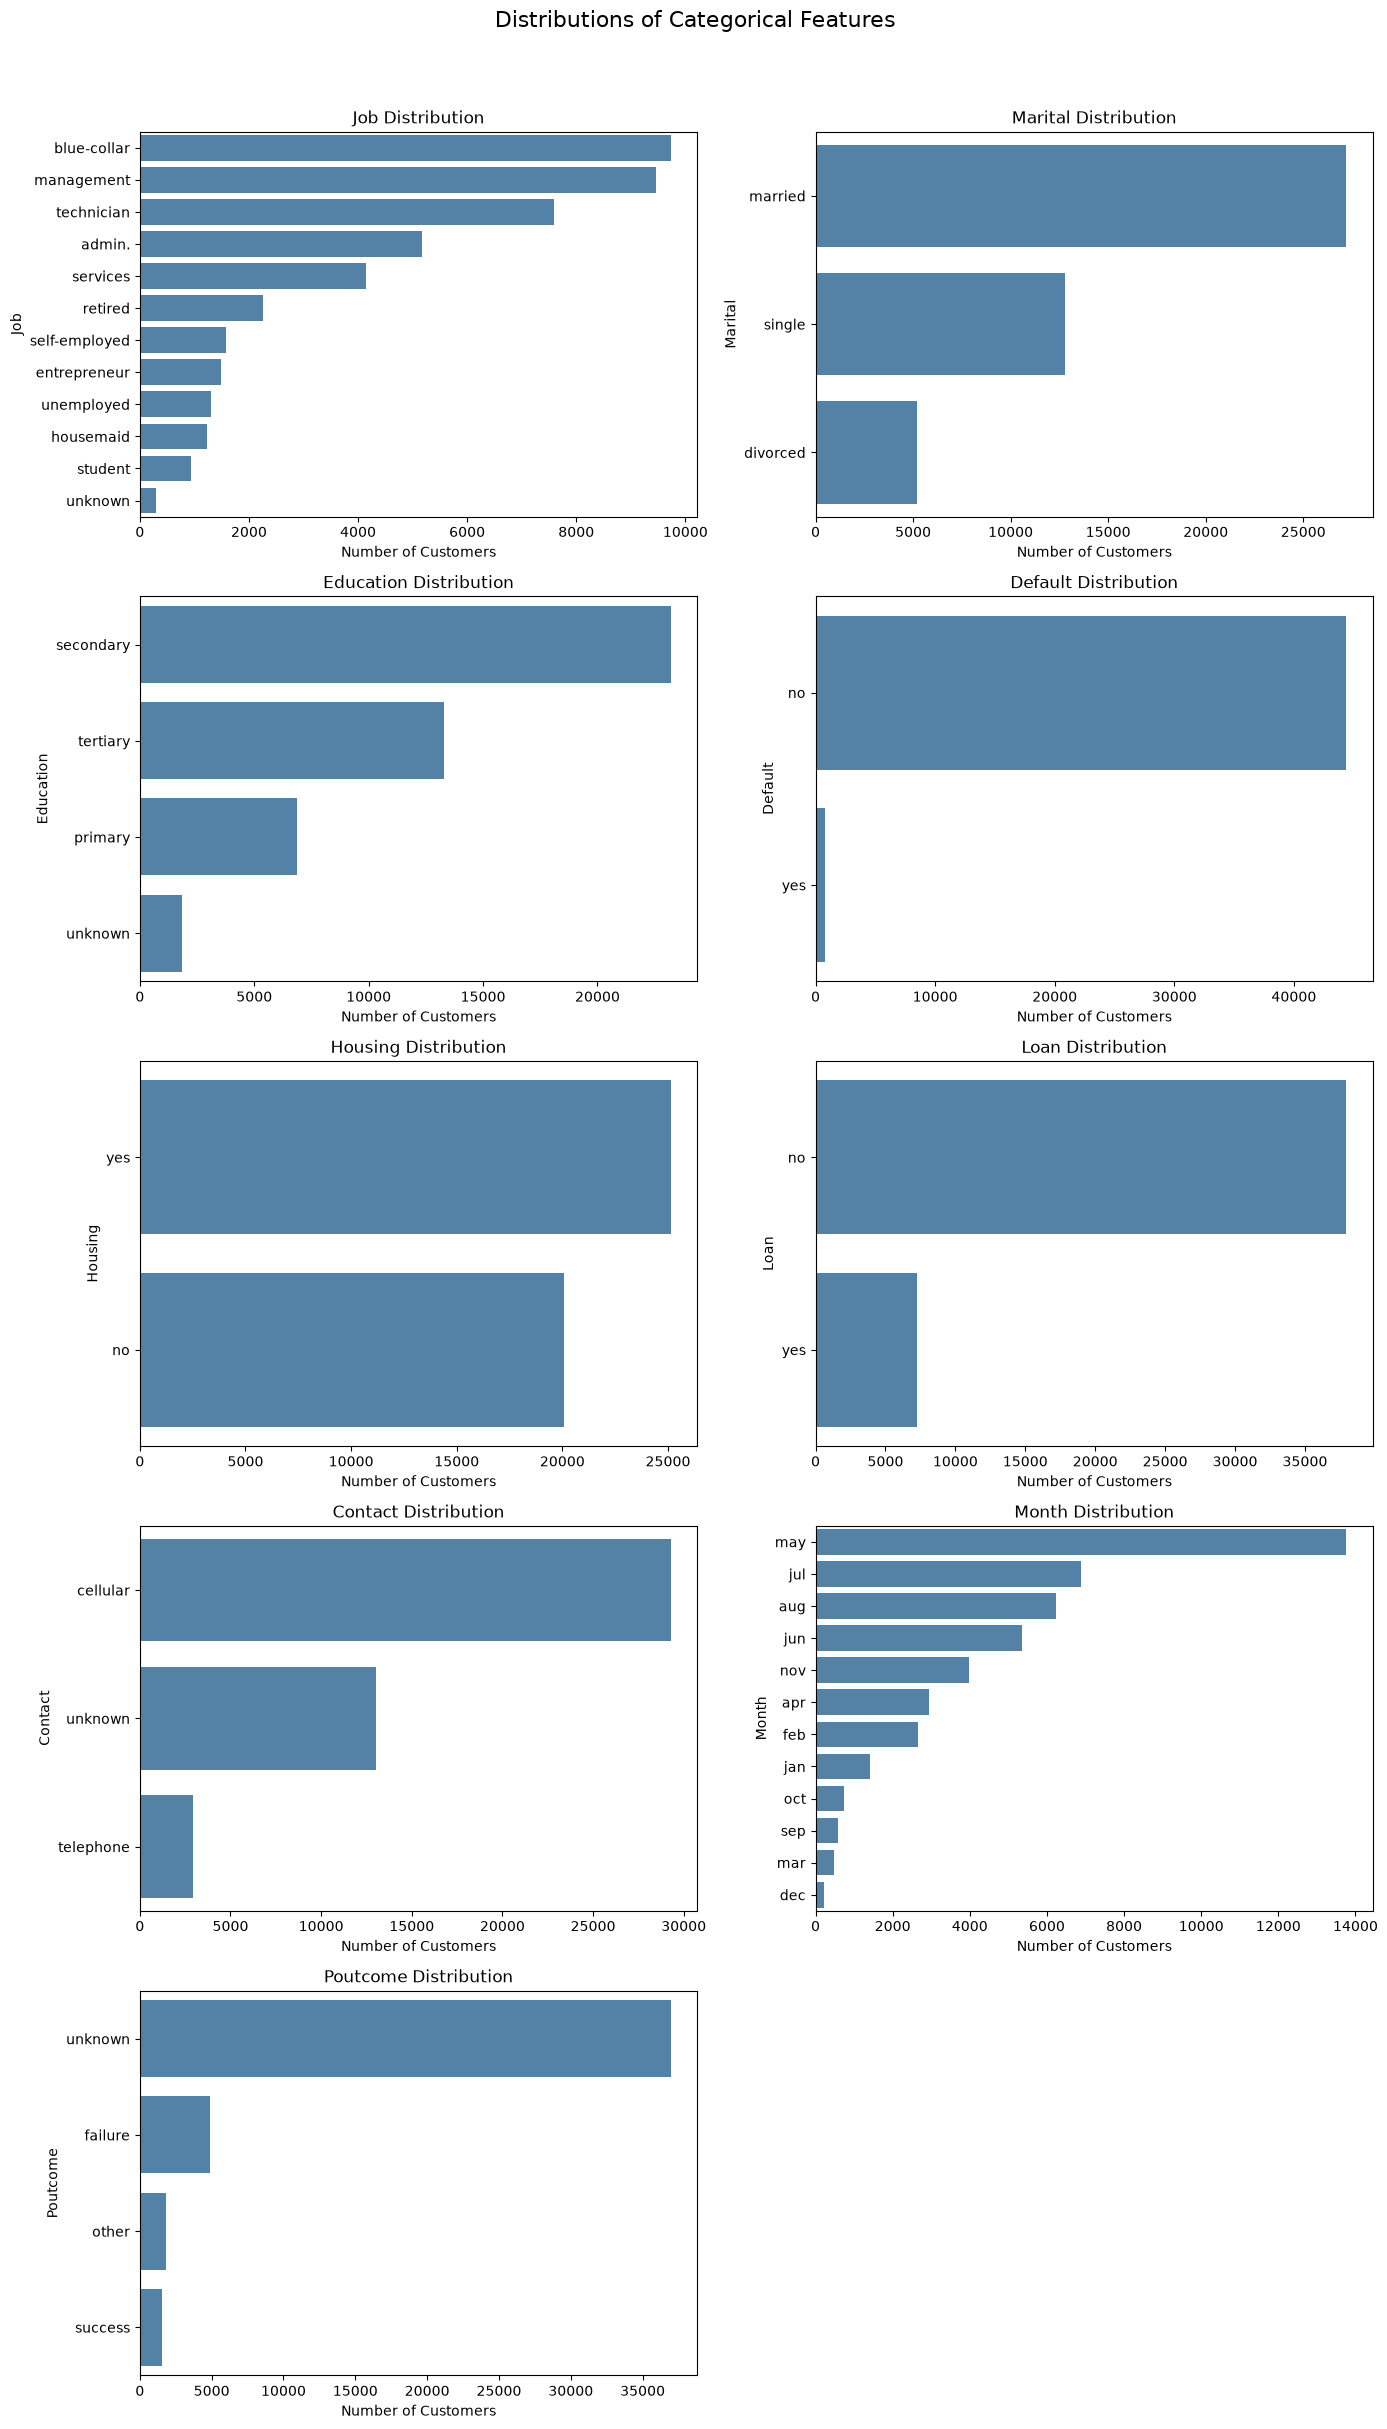

In [23]:
fig, axes = plt.subplots(5, 2, figsize=(14, 24))
axes = axes.flatten()

for index, column in enumerate(categorical_feature_columns):
    category_order = df[column].value_counts().index

    sns.countplot(
        data=df,
        y=column,
        order=category_order,
        ax=axes[index],
        color="steelblue"
    )

    axes[index].set_title(
        f"{column.capitalize()} Distribution"
    )
    axes[index].set_xlabel("Number of Customers")
    axes[index].set_ylabel(column.capitalize())

fig.delaxes(axes[-1])

plt.suptitle(
    "Distributions of Categorical Features",
    fontsize=16,
    y=1.01
)
plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.show()

### Categorical Distribution Observations

- Blue-collar, management, and technician are the most common job categories.
- Most customers are married.
- Secondary education is the most common education level.
- Almost all customers have no credit default.
- Customers with housing loans slightly outnumber those without housing loans.
- Most customers do not have personal loans.
- Cellular is the most common contact method, while many contact values are unknown.
- Most campaign contacts occurred in May.
- Previous campaign outcome is mostly unknown because many customers were not previously contacted.

## 9. Feature Relationships with the Target
### Subscription Rate by Job

In [24]:
job_subscription_rate = (
    pd.crosstab(
        df["job"],
        df["y"],
        normalize="index"
    )
    .mul(100)
    .round(2)
    .sort_values("yes", ascending=False)
)

job_subscription_rate

y,no,yes
job,,
student,71.32,28.68
retired,77.21,22.79
unemployed,84.50,15.50
management,86.24,13.76
admin.,87.80,12.20
self-employed,88.16,11.84
unknown,88.19,11.81
technician,88.94,11.06
services,91.12,8.88


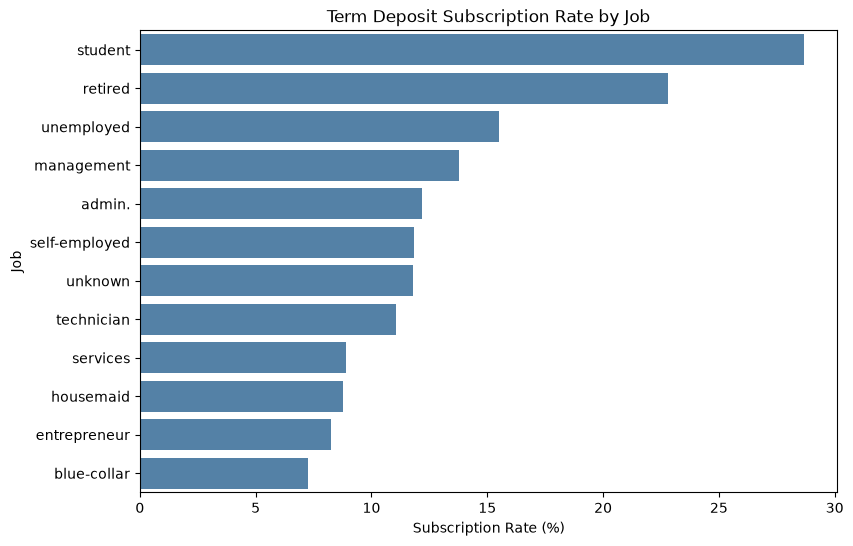

In [25]:
job_rate_plot = job_subscription_rate.reset_index()

plt.figure(figsize=(9, 6))

sns.barplot(
    data=job_rate_plot,
    x="yes",
    y="job",
    color="steelblue"
)

plt.title("Term Deposit Subscription Rate by Job")
plt.xlabel("Subscription Rate (%)")
plt.ylabel("Job")
plt.show()

### Subscription Rate by Other Categorical Features

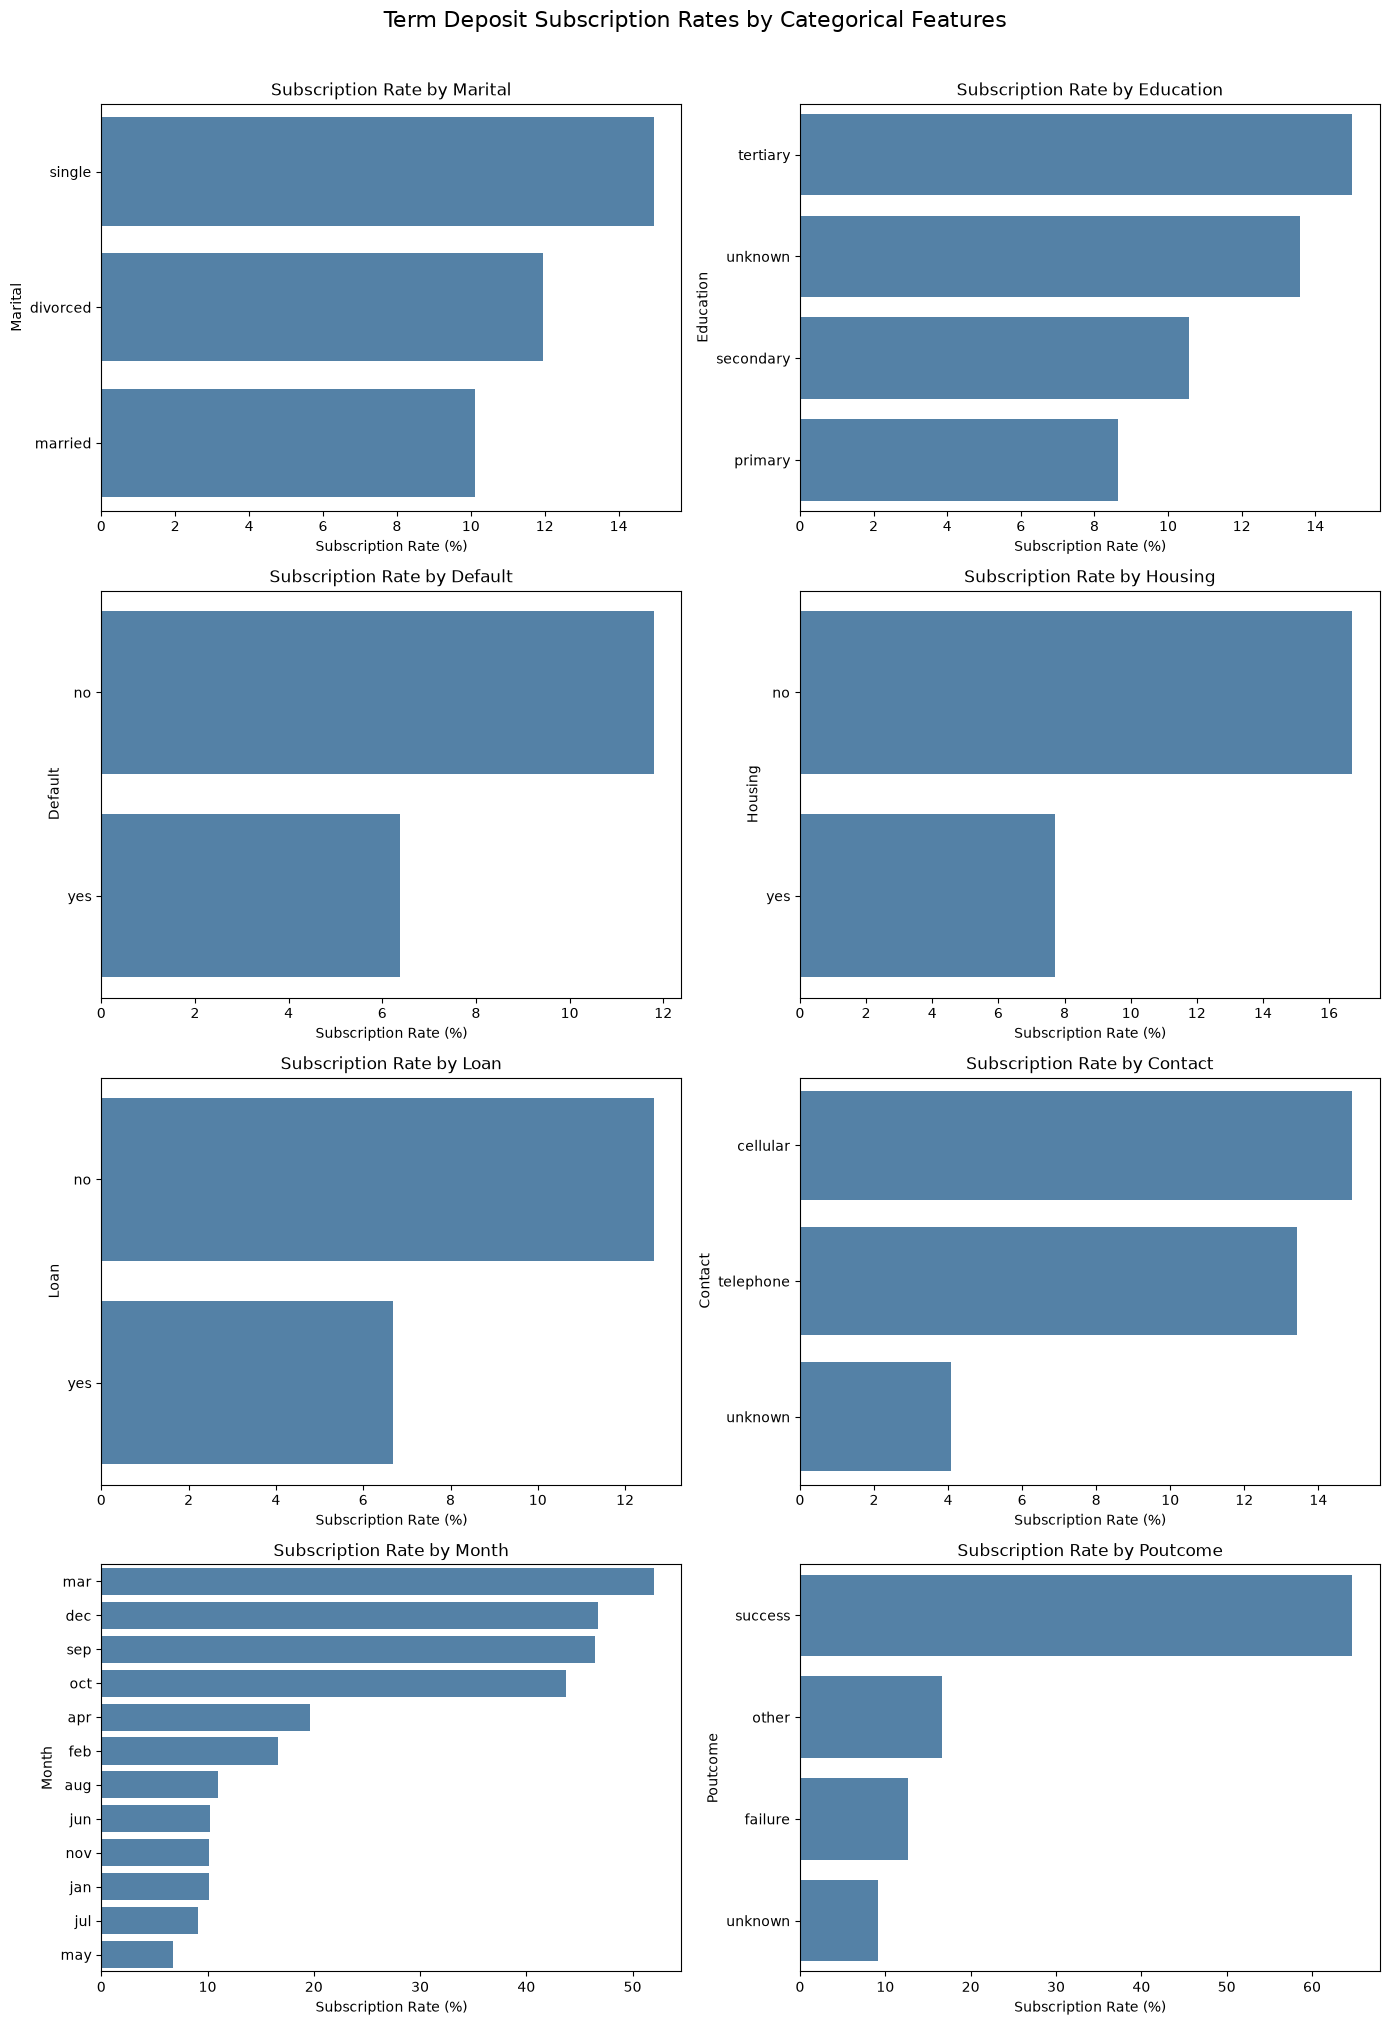

In [26]:
remaining_categorical_columns = [
    column
    for column in categorical_feature_columns
    if column != "job"
]

fig, axes = plt.subplots(4, 2, figsize=(14, 20))
axes = axes.flatten()

for index, column in enumerate(remaining_categorical_columns):
    subscription_rate = (
        pd.crosstab(
            df[column],
            df["y"],
            normalize="index"
        )["yes"]
        .mul(100)
        .sort_values(ascending=False)
    )

    sns.barplot(
        x=subscription_rate.values,
        y=subscription_rate.index,
        ax=axes[index],
        color="steelblue"
    )

    axes[index].set_title(
        f"Subscription Rate by {column.capitalize()}"
    )
    axes[index].set_xlabel("Subscription Rate (%)")
    axes[index].set_ylabel(column.capitalize())

plt.suptitle(
    "Term Deposit Subscription Rates by Categorical Features",
    fontsize=16,
    y=1.01
)
plt.tight_layout()
plt.show()

### Categorical Features and Target Observations

- Single customers have a higher subscription rate than divorced and married customers.
- Customers with tertiary education have the highest subscription rate.
- Customers without credit default are more likely to subscribe.
- Customers without housing loans have a higher subscription rate.
- Customers without personal loans have a higher subscription rate.
- Cellular contact has the highest subscription rate, while unknown contact has the lowest.
- March, December, September, and October show high subscription rates, although some of these months contain fewer observations.
- Customers whose previous campaign outcome was successful have a much higher subscription rate.
- These results show associations and do not prove that any single feature causes subscription.

### Numerical Features by Subscription Outcome

In [27]:
numerical_target_summary = (
    df.groupby("y")[numerical_columns]
    .median()
    .transpose()
    .rename(
        columns={
            "no": "No Median",
            "yes": "Yes Median"
        }
    )
)

numerical_target_summary

y,No Median,Yes Median
age,39.0,38.0
balance,417.0,733.0
day,16.0,15.0
duration,164.0,426.0
campaign,2.0,2.0
pdays,-1.0,-1.0
previous,0.0,0.0


### Numerical Features and Target Observations

- The median age is similar for subscribed and non-subscribed customers.
- Subscribed customers have a higher median balance.
- The median contact day is similar between the two groups.
- Call duration is much higher for subscribed customers, but it will be removed because it is only known after the call and causes data leakage.
- Both groups have the same median campaign contacts.
- The median `pdays` is `-1` for both groups because most customers were not previously contacted.
- The median number of previous contacts is zero for both groups.

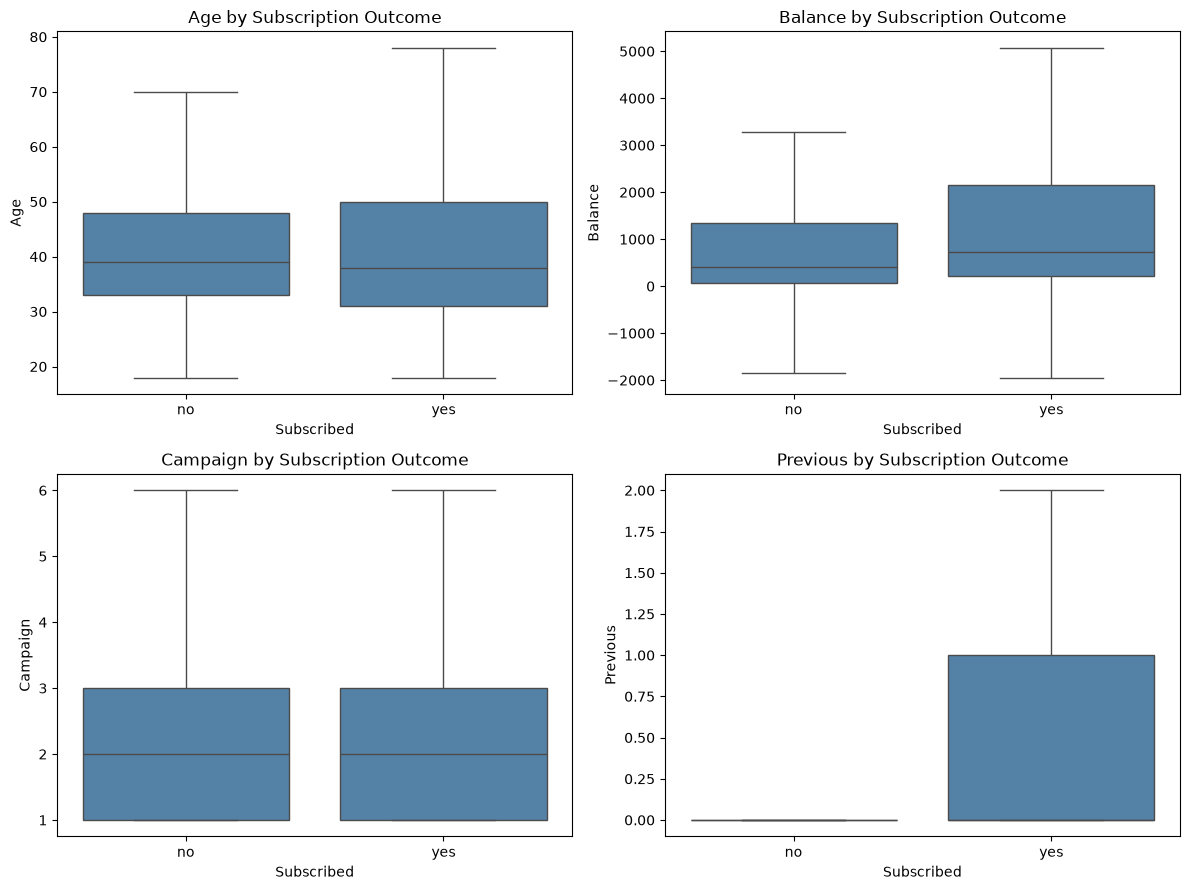

In [28]:
comparison_columns = [
    "age",
    "balance",
    "campaign",
    "previous"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for index, column in enumerate(comparison_columns):
    sns.boxplot(
        data=df,
        x="y",
        y=column,
        ax=axes[index],
        showfliers=False,
        color="steelblue"
    )

    axes[index].set_title(
        f"{column.capitalize()} by Subscription Outcome"
    )
    axes[index].set_xlabel("Subscribed")
    axes[index].set_ylabel(column.capitalize())

plt.tight_layout()
plt.show()


## 10. Correlation Analysis

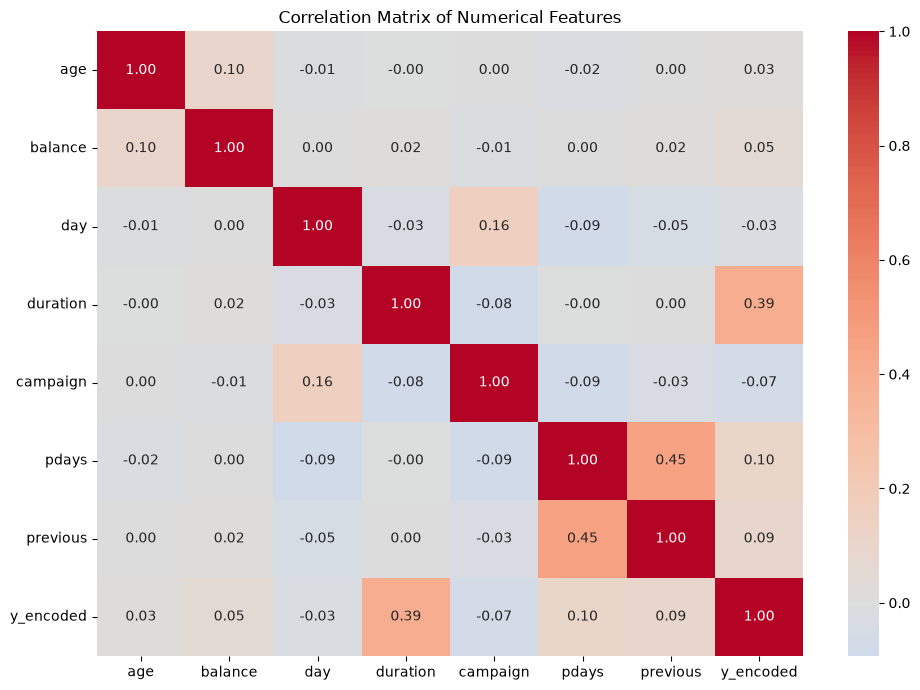

In [29]:
correlation_df = df[numerical_columns].copy()

correlation_df["y_encoded"] = df["y"].map({
    "no": 0,
    "yes": 1
})

correlation_matrix = correlation_df.corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

### Correlation Findings

- Duration has the strongest positive correlation with subscription (`0.39`), but it will be removed to prevent data leakage.
- Pdays and previous have a moderate positive correlation (`0.45`) because both represent previous campaign activity.
- Pdays and previous have small positive correlations with subscription.
- Campaign has a small negative correlation with subscription.
- Age and balance have weak linear correlations with subscription.
- No very strong correlation exists among the retained numerical features.
- Weak Pearson correlation does not mean that a feature is useless because machine learning models can learn nonlinear relationships.

In [31]:
previous_campaign_check = pd.crosstab(
    df["poutcome"],
    df["previous"] == 0
)

previous_campaign_check.columns = [
    "Previously Contacted",
    "Not Previously Contacted"
]

previous_campaign_check

,Previously Contacted,Not Previously Contacted
poutcome,,
failure,4901,0
other,1840,0
success,1511,0
unknown,5,36954


### Previous Campaign Consistency

- Customers with failure, other, or success outcomes were previously contacted.
- Almost all customers with an unknown previous outcome were not previously contacted.
- Therefore, `poutcome = unknown` mainly represents the absence of a previous campaign outcome rather than a data-entry error.
- The unknown category will be retained instead of being imputed with the mode.

In [32]:
validation_summary = pd.Series({
    "age_below_18": (df["age"] < 18).sum(),
    "age_above_100": (df["age"] > 100).sum(),
    "day_outside_1_to_31": (
        (df["day"] < 1) |
        (df["day"] > 31)
    ).sum(),
    "campaign_below_1": (df["campaign"] < 1).sum(),
    "previous_below_0": (df["previous"] < 0).sum(),
    "invalid_target": (~df["y"].isin(["yes", "no"])).sum()
})

validation_summary

age_below_18           0
age_above_100          0
day_outside_1_to_31    0
campaign_below_1       0
previous_below_0       0
invalid_target         0
dtype: int64

## 11. EDA Summary

- The dataset contains 45,211 rows and 17 columns.
- Seven columns are numerical and ten columns are categorical.
- No standard missing values were found.
- No duplicate rows were found.
- No invalid numerical or target values were detected.
- Unknown values occur in job, education, contact, and poutcome.
- The unknown poutcome category mainly represents customers who were not previously contacted, so it will be retained.
- The target is imbalanced: 88.3% of customers did not subscribe and 11.7% subscribed.
- Balance, campaign, age, and previous contain possible outliers, but no rows will be removed without further preprocessing evaluation.
- Customers with higher balances generally show a higher subscription rate.
- Students and retired customers have relatively high subscription rates.
- Customers without housing or personal loans show higher subscription rates.
- A successful previous campaign outcome has a strong relationship with subscription.
- Duration has the strongest numerical relationship with the target, but it will be removed to prevent data leakage.
- Numerical features are measured on different scales and will require scaling during preprocessing.
- Categorical features will require encoding before model training.